In [1]:
import os
import sys
import math
import time
import logging

from mlpng.utils import setup_logging

setup_logging("mlpng.notebook", level=logging.ERROR)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
sys.path.append("/users/stevensonb/Research/tools/deepsphere-cosmo-tf2")

import tensorflow as tf

tf.get_logger().setLevel(logging.ERROR)

import healpy as hp
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from tensorflow.keras.callbacks import EarlyStopping, TerminateOnNaN
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.optimizers.schedules import CosineDecayRestarts, ExponentialDecay
from tensorflow.keras.layers import Dense, Dropout, Flatten, LeakyReLU
from tensorflow.keras.models import load_model

from deepsphere import HealpyGCNN
from deepsphere.healpy_layers import HealpyChebyshev, HealpyPool

from mlpng import Core
from mlpng.utils import rmse_metrics, get_data
from mlpng.utils.dataloaders import KappaDataset

# Setup GPU strategy
gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)
strategy = tf.distribute.MirroredStrategy()

plt.style.use("seaborn-v0_8-paper")
print(
    f"TF {tf.__version__}, GPUs: {len(gpus)}, Strategy: {strategy.num_replicas_in_sync} replicas"
)

2025-12-05 13:15:18.014327: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-12-05 13:15:18.014389: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-12-05 13:15:18.015561: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-05 13:15:18.022650: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-05 13:15:19.166556: W tensorflow/compiler/tf2

TF 2.15.1, GPUs: 1, Strategy: 1 replicas


2025-12-05 13:15:21.112148: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 79194 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-80GB, pci bus id: 0000:90:00.0, compute capability: 8.0


In [ ]:
print("test")

test


In [ ]:
# Configuration
core = Core(
    ["./settings/n256.json", "--shapes", "local", "--nsims", "10000", "--tensorboard"]
)
print(f"nside={core.nside}, npix={core.npix}, shapes={core.shapes}")

# Training settings
BATCH_SIZE = 32
MAX_EPOCHS = 100
PATIENCE = 10
DATA_FRACTION = 0.1
BASE_SPLIT = np.array([0.8, 0.1, 0.1], dtype=np.float32)
DUPLICATES = [25, 10, 10]
PHI_SCALES = [0, 1, 10, 100, 1000]

# Simplified best parameters from Optuna (transformer_levels=0, so no transformer)
best_params = {
    "initial_lr": 0.006063500256249086,
    "pool_p": 2,
    "dropout_rate": 0.15,
    "weight_decay": 3.78e-07,
    "dense_units": 32,
    "dense_layers": 1,
}

# Paths
cache_dir = os.environ.get("SCRATCH", "/tmp") + "/tf_cache"
model_dir = f"{core.dirs['model']}/{core.name}"
os.makedirs(cache_dir, exist_ok=True)
os.makedirs(model_dir, exist_ok=True)

# Compute steps
fractions = BASE_SPLIT * DATA_FRACTION
approx_samples = max(1, int(core.total_sims * fractions[0])) * DUPLICATES[0]
steps_per_epoch = max(1, math.ceil(approx_samples / BATCH_SIZE))
decay_steps = steps_per_epoch * 2
print(f"Steps/epoch: {steps_per_epoch}, Decay steps: {decay_steps}")

nside=256, npix=786432, shapes=['local']
Steps/epoch: 625, Decay steps: 1250


## Simplified Encoder Model (No Transformer)

In [ ]:
class EncoderBlock(tf.keras.layers.Layer):
    """Simplified encoder block: Conv + Dropout + Pool."""

    def __init__(
        self,
        nside,
        npix,
        fin,
        fout,
        K,
        pool_p,
        max_batch_size,
        dropout_rate=0.1,
        **kwargs
    ):
        super().__init__(**kwargs)
        self.config_dict = dict(
            nside=nside,
            npix=npix,
            fin=fin,
            fout=fout,
            K=K,
            pool_p=pool_p,
            max_batch_size=max_batch_size,
            dropout_rate=dropout_rate,
        )
        layers = [
            HealpyChebyshev(
                K=K,
                Fout=fout,
                activation="gelu",
                use_bn=True,
                use_bias=True,
                initializer=tf.keras.initializers.HeNormal(),
            ),
            Dropout(dropout_rate),
            HealpyPool(pool_p, "AVG"),
        ]
        self.body = HealpyGCNN(
            nside=nside,
            indices=np.arange(npix),
            layers=layers,
            n_neighbors=8,
            max_batch_size=max_batch_size,
            initial_Fin=fin,
        )

    def call(self, x, training=False):
        return self.body(x, training=training)

    def get_config(self):
        return {**super().get_config(), **self.config_dict}


def build_encoder_model(npix, npols, n_outputs, params):
    """Build simplified encoder fnl model."""
    nside = hp.npix2nside(npix)
    pool_p = params["pool_p"]
    nside_factor = 2**pool_p
    depth = int(math.log(nside, nside_factor))

    level_nsides = [nside // (nside_factor**i) for i in range(depth + 1)]
    level_npixels = [12 * ns**2 for ns in level_nsides]
    channels = [npols] + [2 ** (i + 5) for i in range(depth + 1)]

    inputs = tf.keras.Input(shape=(npix, npols), name="input")
    x = inputs

    for i in range(depth):
        x = EncoderBlock(
            level_nsides[i],
            level_npixels[i],
            fin=channels[i],
            fout=channels[i + 1],
            K=3,
            pool_p=pool_p,
            max_batch_size=BATCH_SIZE,
            dropout_rate=params["dropout_rate"],
        )(x)

    x = Flatten()(x)
    for _ in range(params["dense_layers"]):
        x = Dense(
            params["dense_units"], activation="gelu", kernel_initializer="he_normal"
        )(x)
    outputs = Dense(n_outputs, kernel_initializer="he_normal")(x)

    return tf.keras.Model(inputs, outputs, name="encoder_fnl")


# Register custom object for model loading
tf.keras.utils.get_custom_objects()["EncoderBlock"] = EncoderBlock

## Jorik SCN Model

In [5]:
def build_jorik_model(npix, npols, n_outputs):
    """Jorik SCN model for fnl estimation."""
    nside = hp.npix2nside(npix)
    n_layers = math.floor(math.log(nside, 2))

    layers = []
    for _ in range(n_layers):
        layers.append(
            HealpyChebyshev(K=2, Fout=32, use_bn=True, activation=LeakyReLU(0.3))
        )
        layers.append(Dropout(0.1))
        layers.append(HealpyPool(1, "AVG"))

    layers.append(Flatten())
    layers.append(Dropout(0.3))
    layers.append(Dense(32, activation=LeakyReLU(0.3)))
    layers.append(Dense(32, activation=LeakyReLU(0.3)))
    layers.append(Dense(n_outputs))

    model = HealpyGCNN(
        nside,
        indices=np.arange(npix),
        layers=layers,
        n_neighbors=8,
        max_batch_size=BATCH_SIZE,
        initial_Fin=npols,
    )
    model.build((None, npix, npols))
    return model

## Helper Functions

In [ ]:
from tensorflow.keras.callbacks import TensorBoard


def create_dataset(x_output, phi_scale=None, cache_suffix=""):
    """Create train/val/test datasets."""
    kwargs = {"x_output": x_output, "y_output": "fnl"}
    if phi_scale is not None:
        kwargs["phi_scale"] = phi_scale
    ds = KappaDataset.fromCore(core, **kwargs)
    return ds.split(
        train_size=float(fractions[0]),
        val_size=float(fractions[1]),
        test_size=float(fractions[2]),
        to_tf=True,
        batch_size=BATCH_SIZE,
        duplicates=DUPLICATES,
        cache_dir=cache_dir,
        cache_file=f"phi-impact-n{core.nside}{cache_suffix}",
        gen_batch_size=16,
    )


def cache_dataset(train_ds, val_ds, test_ds, name=""):
    """Iterate through datasets to populate cache."""
    for ds, split in [(train_ds, "train"), (val_ds, "val"), (test_ds, "test")]:
        for _ in tqdm(ds, desc=f"Caching {name} {split}", leave=False):
            pass


def train_model(
    model, train_ds, val_ds, model_name="model", use_cosine=True, verbose=1
):
    """Train model and return history with timing."""
    lr = best_params["initial_lr"] if use_cosine else 1e-3
    if use_cosine:
        lr_schedule = CosineDecayRestarts(
            lr, decay_steps, t_mul=2.0, m_mul=0.95, alpha=0.01
        )
    else:
        lr_schedule = ExponentialDecay(lr, decay_steps, decay_rate=0.96, staircase=True)

    with strategy.scope():
        optimizer = AdamW(
            learning_rate=lr_schedule,
            weight_decay=best_params.get("weight_decay", 1e-6),
        )
        model.compile(
            optimizer=optimizer, loss="mse", metrics=rmse_metrics(core.shapes)
        )

    callbacks = [
        TerminateOnNaN(),
        EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True),
    ]

    if core.use_tb:
        tb_log_dir = os.path.join(core.dirs["tensorboard"], core.name, model_name)
        callbacks.append(TensorBoard(log_dir=tb_log_dir, histogram_freq=1))

    start = time.time()
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=MAX_EPOCHS,
        steps_per_epoch=steps_per_epoch,
        callbacks=callbacks,
        verbose=verbose,
    )
    train_time = time.time() - start
    return history, train_time


def evaluate_model(model, test_ds):
    """Evaluate model and return predictions, truth, and metrics."""
    preds = model.predict(test_ds, verbose=0)
    truth = np.concatenate([y.numpy() for _, y in test_ds])
    if len(core.shapes) == 1:
        truth, preds = truth.ravel(), preds.ravel()
    rmse = np.sqrt(np.mean((preds - truth) ** 2))
    mae = np.mean(np.abs(preds - truth))
    return preds, truth, rmse, mae


def load_or_train(
    model_path, build_fn, train_ds, val_ds, model_name="model", use_cosine=True
):
    """Load model if exists, otherwise train and save."""
    if os.path.exists(model_path):
        print(f"Loading {model_path}")
        with strategy.scope():
            return load_model(model_path), None, 0

    with strategy.scope():
        model = build_fn()
    history, train_time = train_model(
        model, train_ds, val_ds, model_name=model_name, use_cosine=use_cosine
    )
    model.save(model_path)
    print(f"Saved {model_path}")
    return model, history, train_time


def get_fisher_sigma(lensed=True):
    """Get Fisher sigma from data file."""
    try:
        l_str = "lensed" if lensed else "unlensed"
        fisher = get_data(core.file, f"fisher/{l_str}/{core.shapes[0]}", 0)
        return 1 / np.sqrt(fisher)
    except:
        return None

## Train Jorik Models (Unlensed & Lensed)

In [ ]:
results = {}  # Store all results

# Jorik Unlensed
train_u, val_u, test_u = create_dataset("unlensed", cache_suffix="-unlensed")
cache_dataset(train_u, val_u, test_u, "unlensed")

jorik_unlensed, hist_ju, time_ju = load_or_train(
    f"{model_dir}/jorik-unlensed.keras",
    lambda: build_jorik_model(core.npix, core.npols, len(core.shapes)),
    train_u,
    val_u,
    model_name="jorik-unlensed",
    use_cosine=False,
)
preds_ju, truth_ju, rmse_ju, mae_ju = evaluate_model(jorik_unlensed, test_u)
results["jorik_unlensed"] = {
    "model": jorik_unlensed,
    "history": hist_ju,
    "time": time_ju,
    "preds": preds_ju,
    "truth": truth_ju,
    "rmse": rmse_ju,
    "mae": mae_ju,
}
print(f"Jorik Unlensed - RMSE: {rmse_ju:.4f}, MAE: {mae_ju:.4f}, Time: {time_ju:.1f}s")

In [8]:
# Jorik Lensed (phi_scale=1)
train_l, val_l, test_l = create_dataset(
    "lensed", phi_scale=1.0, cache_suffix="-lensed-phi1"
)
cache_dataset(train_l, val_l, test_l, "lensed-phi1")

jorik_lensed, hist_jl, time_jl = load_or_train(
    f"{model_dir}/jorik-lensed.keras",
    lambda: build_jorik_model(core.npix, core.npols, len(core.shapes)),
    train_l,
    val_l,
    model_name="jorik-lensed",
    use_cosine=False,
)
preds_jl, truth_jl, rmse_jl, mae_jl = evaluate_model(jorik_lensed, test_l)
results["jorik_lensed"] = {
    "model": jorik_lensed,
    "history": hist_jl,
    "time": time_jl,
    "preds": preds_jl,
    "truth": truth_jl,
    "rmse": rmse_jl,
    "mae": mae_jl,
}
print(f"Jorik Lensed - RMSE: {rmse_jl:.4f}, MAE: {mae_jl:.4f}, Time: {time_jl:.1f}s")

Caching lensed-phi1 train:   0%|          | 0/625 [00:00<?, ?it/s]

Caching lensed-phi1 val:   0%|          | 0/32 [00:00<?, ?it/s]

Caching lensed-phi1 test:   0%|          | 0/32 [00:00<?, ?it/s]

Loading data/models/l767_n256_T_10000_p1.0/jorik-lensed.keras


2025-12-05 11:48:22.344095: W tensorflow/core/grappler/optimizers/data/auto_shard.cc:553] The `assert_cardinality` transformation is currently not handled by the auto-shard rewrite and will be removed.


Jorik Lensed - RMSE: 32.6952, MAE: 25.7934, Time: 0.0s


## Train CNN Range Model (phi_scale 0-1000)

In [9]:
train_r, val_r, test_r = create_dataset(
    "lensed", phi_scale=(0, 1000), cache_suffix="-range"
)
cache_dataset(train_r, val_r, test_r, "range")

cnn_range, hist_cr, time_cr = load_or_train(
    f"{model_dir}/encoder-range.keras",
    lambda: build_encoder_model(core.npix, core.npols, len(core.shapes), best_params),
    train_r,
    val_r,
    model_name="encoder-range",
    use_cosine=True,
)
preds_cr, truth_cr, rmse_cr, mae_cr = evaluate_model(cnn_range, test_r)
results["cnn_range"] = {
    "model": cnn_range,
    "history": hist_cr,
    "time": time_cr,
    "preds": preds_cr,
    "truth": truth_cr,
    "rmse": rmse_cr,
    "mae": mae_cr,
}
print(f"CNN Range - RMSE: {rmse_cr:.4f}, MAE: {mae_cr:.4f}, Time: {time_cr:.1f}s")

Caching range train:   0%|          | 0/625 [00:00<?, ?it/s]

Caching range val:   0%|          | 0/32 [00:00<?, ?it/s]

Caching range test:   0%|          | 0/32 [00:00<?, ?it/s]

Loading data/models/l767_n256_T_10000_p1.0/encoder-range.keras


2025-12-05 12:01:23.852047: W tensorflow/core/grappler/optimizers/data/auto_shard.cc:553] The `assert_cardinality` transformation is currently not handled by the auto-shard rewrite and will be removed.


CNN Range - RMSE: 87.8870, MAE: 70.8990, Time: 0.0s


## Train Phi-Specific Models

In [10]:
from IPython.display import clear_output

phi_models = {}

for phi in tqdm(PHI_SCALES, desc="Training phi-specific models"):
    clear_output(wait=True)
    print(f"Processing phi={phi}...")

    train_p, val_p, test_p = create_dataset(
        "lensed", phi_scale=float(phi), cache_suffix=f"-phi{phi}"
    )
    cache_dataset(train_p, val_p, test_p, f"phi{phi}")

    model_p, hist_p, time_p = load_or_train(
        f"{model_dir}/encoder-phi{phi}.keras",
        lambda: build_encoder_model(
            core.npix, core.npols, len(core.shapes), best_params
        ),
        train_p,
        val_p,
        model_name=f"encoder-phi{phi}",
        use_cosine=True,
    )

    preds_p, truth_p, rmse_p, mae_p = evaluate_model(model_p, test_p)
    phi_models[phi] = {
        "model": model_p,
        "history": hist_p,
        "time": time_p,
        "preds": preds_p,
        "truth": truth_p,
        "rmse": rmse_p,
        "mae": mae_p,
        "test_ds": test_p,
    }
    print(f"phi={phi}: RMSE={rmse_p:.4f}, MAE={mae_p:.4f}, Time={time_p:.1f}s")

# Final summary after loop
clear_output(wait=True)
print("Training complete! Results:")
for phi in PHI_SCALES:
    data = phi_models[phi]
    print(
        f"phi={phi}: RMSE={data['rmse']:.4f}, MAE={data['mae']:.4f}, Time={data['time']:.1f}s"
    )

Training complete! Results:
phi=0: RMSE=20.2047, MAE=15.9983, Time=0.0s
phi=1: RMSE=19.8214, MAE=15.7701, Time=0.0s
phi=10: RMSE=30.1839, MAE=24.1130, Time=0.0s
phi=100: RMSE=45.8780, MAE=36.1987, Time=0.0s
phi=1000: RMSE=83.5917, MAE=67.1772, Time=0.0s


## Impact Plot: RMSE vs Phi-Scale

2025-12-05 13:05:00.704115: W tensorflow/core/grappler/optimizers/data/auto_shard.cc:553] The `assert_cardinality` transformation is currently not handled by the auto-shard rewrite and will be removed.
2025-12-05 13:05:10.966083: W tensorflow/core/grappler/optimizers/data/auto_shard.cc:553] The `assert_cardinality` transformation is currently not handled by the auto-shard rewrite and will be removed.
2025-12-05 13:05:21.255882: W tensorflow/core/grappler/optimizers/data/auto_shard.cc:553] The `assert_cardinality` transformation is currently not handled by the auto-shard rewrite and will be removed.
2025-12-05 13:05:25.944968: W tensorflow/core/grappler/optimizers/data/auto_shard.cc:553] The `assert_cardinality` transformation is currently not handled by the auto-shard rewrite and will be removed.
2025-12-05 13:05:36.224775: W tensorflow/core/grappler/optimizers/data/auto_shard.cc:553] The `assert_cardinality` transformation is currently not handled by the auto-shard rewrite and will be

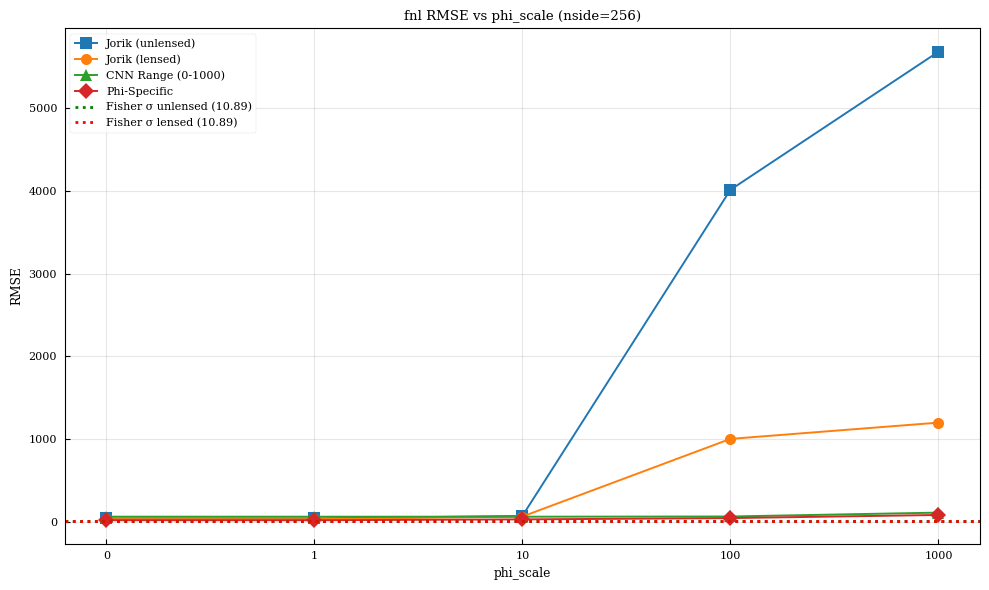

In [11]:
# Evaluate all models at each phi_scale
impact = {"jorik_unlensed": [], "jorik_lensed": [], "cnn_range": [], "phi_specific": []}

for phi in PHI_SCALES:
    test_ds = phi_models[phi]["test_ds"]

    # Jorik unlensed (use unlensed test set for phi=0, otherwise lensed)
    if phi == 0:
        _, _, rmse, _ = evaluate_model(jorik_unlensed, test_u)
    else:
        _, _, rmse, _ = evaluate_model(jorik_unlensed, test_ds)
    impact["jorik_unlensed"].append(rmse)

    # Jorik lensed
    _, _, rmse, _ = evaluate_model(jorik_lensed, test_ds)
    impact["jorik_lensed"].append(rmse)

    # CNN range
    _, _, rmse, _ = evaluate_model(cnn_range, test_ds)
    impact["cnn_range"].append(rmse)

    # Phi-specific
    impact["phi_specific"].append(phi_models[phi]["rmse"])

# Get Fisher bounds
sigma_unlensed = get_fisher_sigma(lensed=False)
sigma_lensed = get_fisher_sigma(lensed=True)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(PHI_SCALES))

ax.plot(x, impact["jorik_unlensed"], "s-", label="Jorik (unlensed)", markersize=8)
ax.plot(x, impact["jorik_lensed"], "o-", label="Jorik (lensed)", markersize=8)
ax.plot(x, impact["cnn_range"], "^-", label="CNN Range (0-1000)", markersize=8)
ax.plot(x, impact["phi_specific"], "D-", label="Phi-Specific", markersize=8)

if sigma_unlensed:
    ax.axhline(
        sigma_unlensed,
        color="green",
        linestyle=":",
        lw=2,
        label=f"Fisher σ unlensed ({sigma_unlensed:.2f})",
    )
if sigma_lensed:
    ax.axhline(
        sigma_lensed,
        color="red",
        linestyle=":",
        lw=2,
        label=f"Fisher σ lensed ({sigma_lensed:.2f})",
    )

ax.set_xticks(x)
ax.set_xticklabels(PHI_SCALES)
ax.set_xlabel("phi_scale")
ax.set_ylabel("RMSE")
ax.set_title(f"fnl RMSE vs phi_scale (nside={core.nside})")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Scatter Plots: Predictions vs Truth

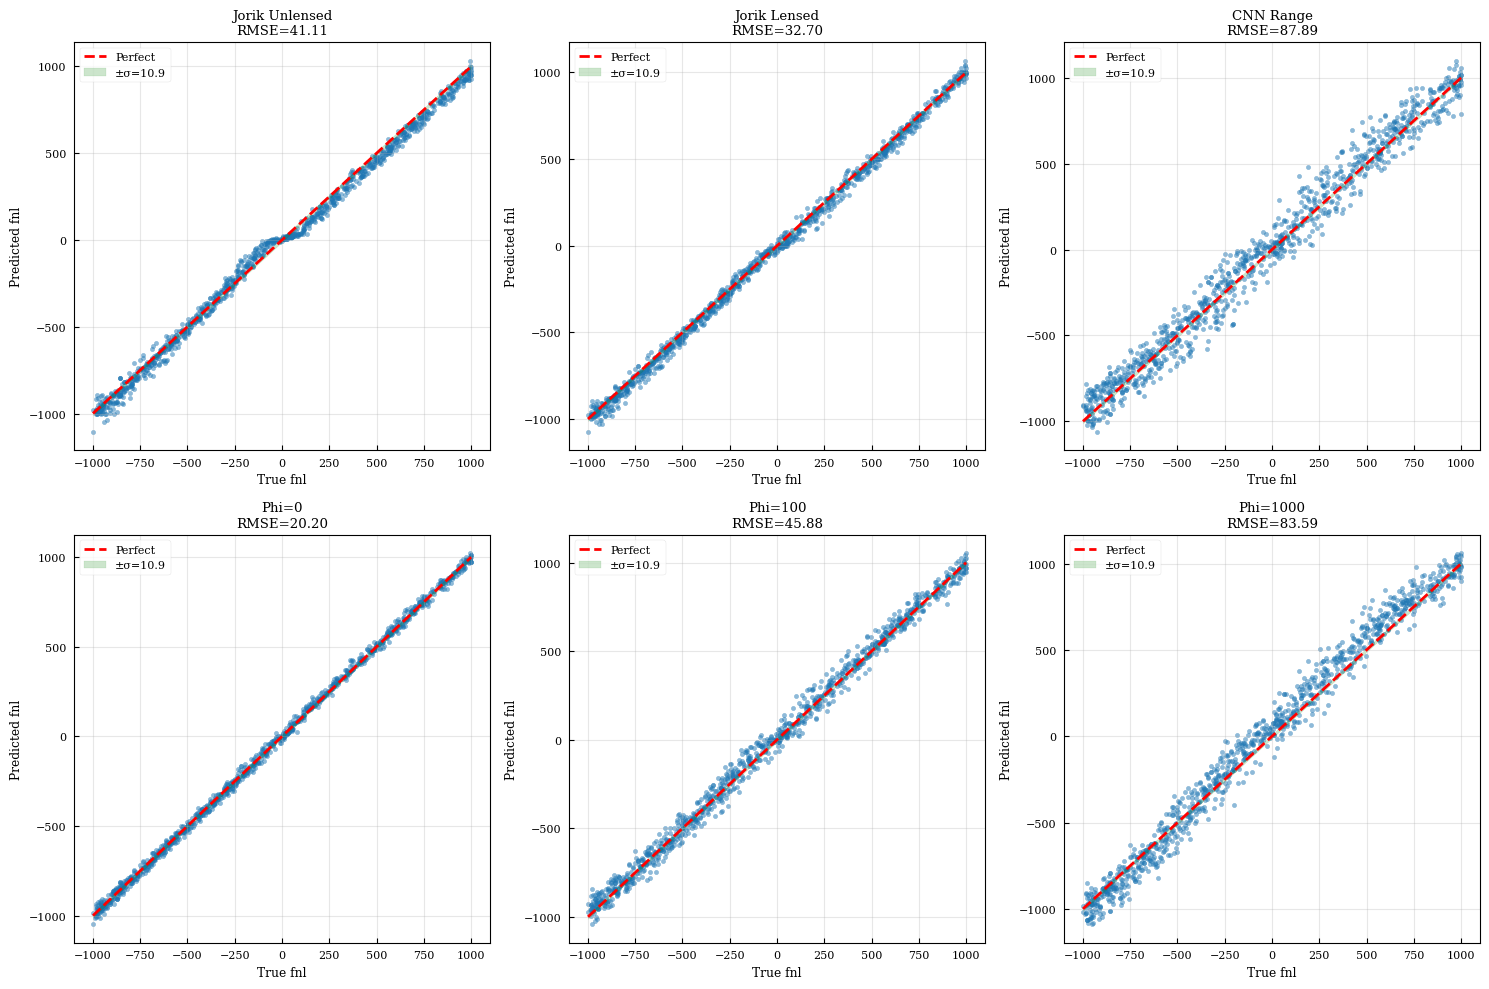

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
sigma = sigma_lensed or 50

plot_data = [
    ("Jorik Unlensed", results["jorik_unlensed"]),
    ("Jorik Lensed", results["jorik_lensed"]),
    ("CNN Range", results["cnn_range"]),
    ("Phi=0", phi_models[0]),
    ("Phi=100", phi_models[100]),
    ("Phi=1000", phi_models[1000]),
]

for ax, (name, data) in zip(axes.flat, plot_data):
    truth, preds = data["truth"], data["preds"]
    line = np.array([np.nanmin(truth), np.nanmax(truth)])
    ax.scatter(truth, preds, alpha=0.5, s=10)
    ax.plot(line, line, "r--", lw=2, label="Perfect")
    ax.fill_between(
        line,
        line - sigma,
        line + sigma,
        alpha=0.2,
        color="green",
        label=f"±σ={sigma:.1f}",
    )
    ax.set_xlabel("True fnl")
    ax.set_ylabel("Predicted fnl")
    ax.set_title(f"{name}\nRMSE={data['rmse']:.2f}")
    ax.legend(loc="upper left", fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Loss Curves

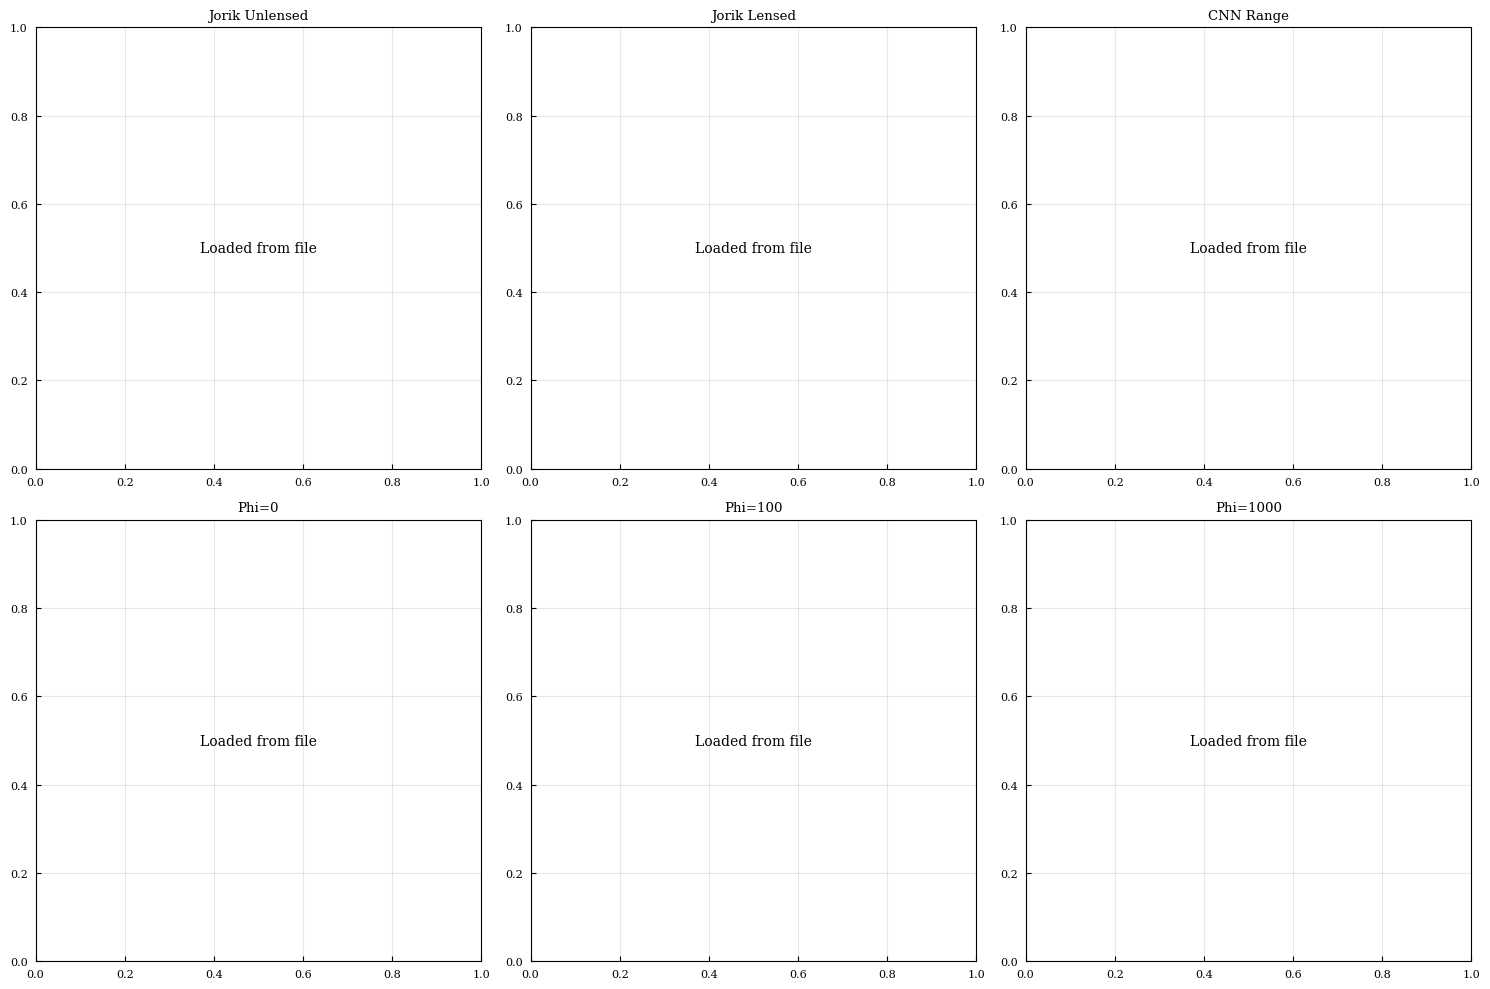

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for ax, (name, data) in zip(axes.flat, plot_data):
    if data["history"] is not None:
        ax.plot(data["history"].history["loss"], label="Train")
        ax.plot(data["history"].history["val_loss"], label="Val")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss (MSE)")
        ax.legend()
    else:
        ax.text(
            0.5,
            0.5,
            "Loaded from file",
            ha="center",
            va="center",
            transform=ax.transAxes,
        )
    ax.set_title(name)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Inference Error vs Phi-Scale

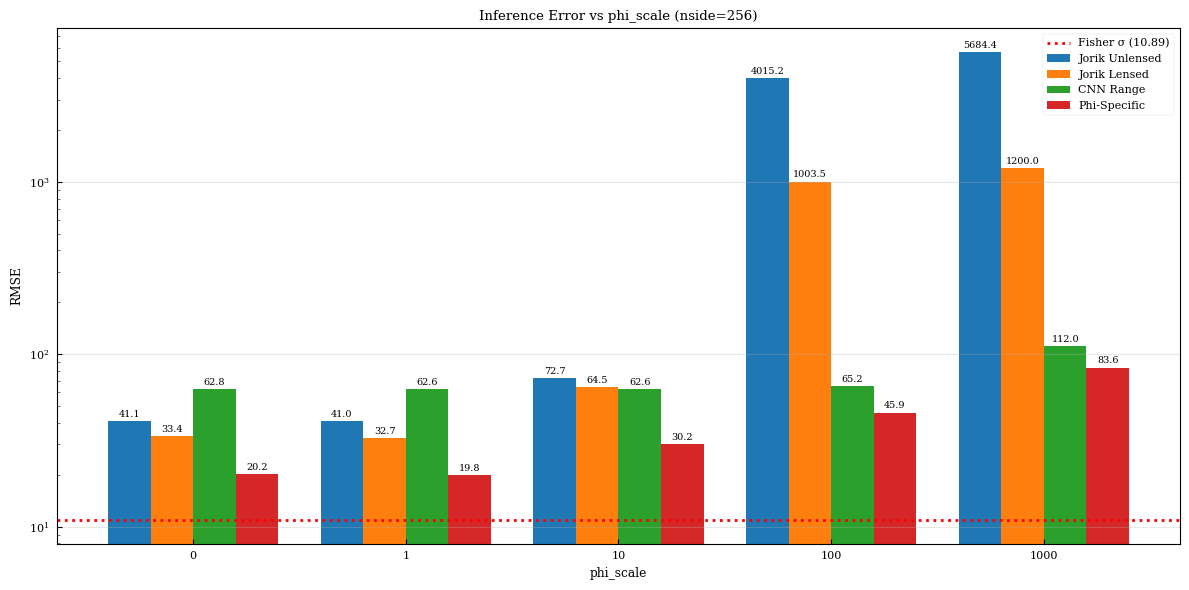

In [14]:
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(PHI_SCALES))
width = 0.2

bars1 = ax.bar(x - 1.5 * width, impact["jorik_unlensed"], width, label="Jorik Unlensed")
bars2 = ax.bar(x - 0.5 * width, impact["jorik_lensed"], width, label="Jorik Lensed")
bars3 = ax.bar(x + 0.5 * width, impact["cnn_range"], width, label="CNN Range")
bars4 = ax.bar(x + 1.5 * width, impact["phi_specific"], width, label="Phi-Specific")

if sigma_lensed:
    ax.axhline(
        sigma_lensed,
        color="red",
        linestyle=":",
        lw=2,
        label=f"Fisher σ ({sigma_lensed:.2f})",
    )

ax.set_xticks(x)
ax.set_xticklabels(PHI_SCALES)
ax.set_xlabel("phi_scale")
ax.set_ylabel("RMSE")
ax.set_title(f"Inference Error vs phi_scale (nside={core.nside})")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
ax.set_yscale("log")

# Add value labels
for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(
            f"{h:.1f}",
            xy=(bar.get_x() + bar.get_width() / 2, h),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            fontsize=7,
        )

plt.tight_layout()
plt.show()

## Summary Table

In [15]:
print("\nSummary: Model Performance")
print("=" * 70)
print(f"{'Model':<20} {'RMSE':<10} {'MAE':<10} {'Time (s)':<10} {'Val Loss':<12}")
print("-" * 70)

for name, data in [
    ("Jorik Unlensed", results["jorik_unlensed"]),
    ("Jorik Lensed", results["jorik_lensed"]),
    ("CNN Range", results["cnn_range"]),
]:
    val_loss = min(data["history"].history["val_loss"]) if data["history"] else "N/A"
    print(
        f"{name:<20} {data['rmse']:<10.4f} {data['mae']:<10.4f} {data['time']:<10.1f} {val_loss if isinstance(val_loss, str) else f'{val_loss:.6f}':<12}"
    )

for phi in PHI_SCALES:
    data = phi_models[phi]
    val_loss = min(data["history"].history["val_loss"]) if data["history"] else "N/A"
    print(
        f"Phi={phi:<14} {data['rmse']:<10.4f} {data['mae']:<10.4f} {data['time']:<10.1f} {val_loss if isinstance(val_loss, str) else f'{val_loss:.6f}':<12}"
    )

print("=" * 70)
if sigma_unlensed:
    print(f"Fisher σ (unlensed): {sigma_unlensed:.4f}")
if sigma_lensed:
    print(f"Fisher σ (lensed): {sigma_lensed:.4f}")


Summary: Model Performance
Model                RMSE       MAE        Time (s)   Val Loss    
----------------------------------------------------------------------
Jorik Unlensed       41.1140    33.6951    0.0        N/A         
Jorik Lensed         32.6952    25.7934    0.0        N/A         
CNN Range            87.8870    70.8990    0.0        N/A         
Phi=0              20.2047    15.9983    0.0        N/A         
Phi=1              19.8214    15.7701    0.0        N/A         
Phi=10             30.1839    24.1130    0.0        N/A         
Phi=100            45.8780    36.1987    0.0        N/A         
Phi=1000           83.5917    67.1772    0.0        N/A         
Fisher σ (unlensed): 10.8899
Fisher σ (lensed): 10.8898


## Delta N² Lensing Bias Calculation

Compute the 4-point lensing bias contribution (delta N²) for each phi_scale using Vegas integration.

In [16]:
import camb
import vegas
import numba
from math import sqrt
from scipy.interpolate import interp1d


# Numba helper functions for delta N² calculation
@numba.njit(nogil=True, fastmath=False)
def numba_trapezoid(y, x):
    """Trapezoidal integration for numba."""
    n = len(x)
    integral = 0.0
    for i in range(1, n):
        integral += (x[i] - x[i - 1]) * (y[i] + y[i - 1]) / 2.0
    return integral


@numba.njit(nogil=True, fastmath=False)
def compute_bispectrum_local(alpha, beta, l1, l2, l3, rs):
    """Compute local bispectrum."""
    integrand = (
        rs
        * rs
        * (
            beta[l3] * beta[l2] * alpha[l1]
            + beta[l1] * beta[l3] * alpha[l2]
            + beta[l2] * beta[l1] * alpha[l3]
        )
    )
    return 6.0 / 5.0 * numba_trapezoid(integrand, x=rs)


@numba.njit(nogil=True, fastmath=False)
def compute_W(l1, l2, l3, c_ell, radii, alpha, beta):
    """Compute W weight function."""
    C6 = 6.0 * c_ell[l1] * c_ell[l2] * c_ell[l3]
    B = compute_bispectrum_local(alpha, beta, l1, l2, l3, radii)
    return 4 * np.pi * np.pi * B / C6


@numba.njit(nogil=True, fastmath=False)
def tri_single(lmax, c_ell, c_ell_phi, l1_0, l1_1, l2_0, l2_1, l3_0, l3_1, l4_0, l4_1):
    """Single trispectrum term."""
    l13_0 = l1_0 + l3_0
    l13_1 = l1_1 + l3_1
    l24_0 = l2_0 + l4_0
    l24_1 = l2_1 + l4_1

    l13_mag = int(round(sqrt(l13_0 * l13_0 + l13_1 * l13_1)))
    l3_mag = int(round(sqrt(l3_0 * l3_0 + l3_1 * l3_1)))
    l4_mag = int(round(sqrt(l4_0 * l4_0 + l4_1 * l4_1)))

    if not (2 < l3_mag <= lmax and 2 < l4_mag <= lmax and 2 < l13_mag <= lmax):
        return 0.0

    l13_3 = l13_0 * l3_0 + l13_1 * l3_1
    l24_4 = l24_0 * l4_0 + l24_1 * l4_1
    return c_ell_phi[l13_mag] * c_ell[l3_mag] * c_ell[l4_mag] * l13_3 * l24_4


@numba.njit(nogil=True, fastmath=False)
def tri(lmax, c_ell, c_ell_phi, l1_0, l1_1, l2_0, l2_1, l3_0, l3_1, l4_0, l4_1):
    """Full trispectrum with all permutations."""
    value = 0.0
    # All 12 permutations
    value += tri_single(
        lmax, c_ell, c_ell_phi, l1_0, l1_1, l2_0, l2_1, l3_0, l3_1, l4_0, l4_1
    )
    value += tri_single(
        lmax, c_ell, c_ell_phi, l1_0, l1_1, l2_0, l2_1, l4_0, l4_1, l3_0, l3_1
    )
    value += tri_single(
        lmax, c_ell, c_ell_phi, l1_0, l1_1, l3_0, l3_1, l2_0, l2_1, l4_0, l4_1
    )
    value += tri_single(
        lmax, c_ell, c_ell_phi, l1_0, l1_1, l3_0, l3_1, l4_0, l4_1, l2_0, l2_1
    )
    value += tri_single(
        lmax, c_ell, c_ell_phi, l1_0, l1_1, l4_0, l4_1, l2_0, l2_1, l3_0, l3_1
    )
    value += tri_single(
        lmax, c_ell, c_ell_phi, l1_0, l1_1, l4_0, l4_1, l3_0, l3_1, l2_0, l2_1
    )
    value += tri_single(
        lmax, c_ell, c_ell_phi, l2_0, l2_1, l1_0, l1_1, l3_0, l3_1, l4_0, l4_1
    )
    value += tri_single(
        lmax, c_ell, c_ell_phi, l2_0, l2_1, l1_0, l1_1, l4_0, l4_1, l3_0, l3_1
    )
    value += tri_single(
        lmax, c_ell, c_ell_phi, l2_0, l2_1, l3_0, l3_1, l1_0, l1_1, l4_0, l4_1
    )
    value += tri_single(
        lmax, c_ell, c_ell_phi, l2_0, l2_1, l3_0, l3_1, l4_0, l4_1, l1_0, l1_1
    )
    value += tri_single(
        lmax, c_ell, c_ell_phi, l2_0, l2_1, l4_0, l4_1, l1_0, l1_1, l3_0, l3_1
    )
    value += tri_single(
        lmax, c_ell, c_ell_phi, l2_0, l2_1, l4_0, l4_1, l3_0, l3_1, l1_0, l1_1
    )
    return value / 2.0


@numba.njit(nogil=True, fastmath=False)
def delta_n2_integrand_scalar(x, lmax, c_ell, c_ell_lens, cl_phi, alpha, beta, radii):
    """Scalar integrand for delta N² calculation."""
    l1_0, l1_1 = x[0], x[1]
    l2_0, l2_1 = x[2], x[3]
    lp2_0, lp2_1 = x[4], x[5]

    l3_0, l3_1 = -l1_0 - l2_0, -l1_1 - l2_1
    lp1_0, lp1_1 = -l1_0, -l1_1
    lp3_0, lp3_1 = -l2_0 - l3_0 - lp2_0, -l2_1 - l3_1 - lp2_1

    lm = lmax
    if not (
        -lm <= l3_0 <= lm
        and -lm <= l3_1 <= lm
        and -lm <= lp1_0 <= lm
        and -lm <= lp1_1 <= lm
        and -lm <= lp3_0 <= lm
        and -lm <= lp3_1 <= lm
    ):
        return 0.0

    l1 = int(round(sqrt(l1_0 * l1_0 + l1_1 * l1_1)))
    l2 = int(round(sqrt(l2_0 * l2_0 + l2_1 * l2_1)))
    l3 = int(round(sqrt(l3_0 * l3_0 + l3_1 * l3_1)))
    lp1 = int(round(sqrt(lp1_0 * lp1_0 + lp1_1 * lp1_1)))
    lp2 = int(round(sqrt(lp2_0 * lp2_0 + lp2_1 * lp2_1)))
    lp3 = int(round(sqrt(lp3_0 * lp3_0 + lp3_1 * lp3_1)))

    if not (
        2 < l1 <= lmax
        and 2 < l2 <= lmax
        and 2 < l3 <= lmax
        and 2 < lp1 <= lmax
        and 2 < lp2 <= lmax
        and 2 < lp3 <= lmax
    ):
        return 0.0

    W = compute_W(l1, l2, l3, c_ell, radii, alpha, beta)
    Wp = compute_W(lp1, lp2, lp3, c_ell, radii, alpha, beta)
    T = tri(lmax, c_ell, cl_phi, l2_0, l2_1, l3_0, l3_1, lp2_0, lp2_1, lp3_0, lp3_1)
    return W * Wp * c_ell_lens[l1] * T


@numba.njit(parallel=True, nogil=True, fastmath=False)
def delta_n2_integrand_batch(
    x_batch, lmax, c_ell, c_ell_lens, cl_phi, alpha, beta, radii
):
    """Batch integrand for Vegas."""
    n = x_batch.shape[0]
    out = np.zeros(n, dtype=np.float64)
    for i in numba.prange(n):
        out[i] = delta_n2_integrand_scalar(
            x_batch[i], lmax, c_ell, c_ell_lens, cl_phi, alpha, beta, radii
        )
    return out


class DeltaN2IntegrandNumbaVec(vegas.LBatchIntegrand):
    """Vegas integrand class for delta N²."""

    def __init__(self, lmax, c_ell, c_ell_lens, cl_phi, alpha, beta, radii):
        self.lmax = lmax
        self.c_ell = c_ell
        self.c_ell_lens = c_ell_lens
        self.cl_phi = cl_phi
        self.alpha = alpha
        self.beta = beta
        self.radii = radii

    def __call__(self, x):
        return delta_n2_integrand_batch(
            x,
            self.lmax,
            self.c_ell,
            self.c_ell_lens,
            self.cl_phi,
            self.alpha,
            self.beta,
            self.radii,
        )


# S (signal) integrand - needed to normalize delta N² properly
@numba.njit(nogil=True, fastmath=False)
def s_integrand_scalar(x, lmax, c_ell, alpha, beta, radii):
    """Scalar integrand for S (signal) calculation."""
    l1_0, l1_1 = x[0], x[1]
    l2_0, l2_1 = x[2], x[3]
    l3_0, l3_1 = -l1_0 - l2_0, -l1_1 - l2_1

    l1_mag = int(round(sqrt(l1_0 * l1_0 + l1_1 * l1_1)))
    l2_mag = int(round(sqrt(l2_0 * l2_0 + l2_1 * l2_1)))
    l3_mag = int(round(sqrt(l3_0 * l3_0 + l3_1 * l3_1)))

    if not (2 < l1_mag <= lmax and 2 < l2_mag <= lmax and 2 < l3_mag <= lmax):
        return 0.0

    W = compute_W(l1_mag, l2_mag, l3_mag, c_ell, radii, alpha, beta)
    B = compute_bispectrum_local(alpha, beta, l1_mag, l2_mag, l3_mag, radii)
    return W * B


@numba.njit(parallel=True, nogil=True, fastmath=False)
def s_integrand_batch(x_batch, lmax, c_ell, alpha, beta, radii):
    """Batch integrand for S (signal) Vegas integration."""
    n = x_batch.shape[0]
    out = np.zeros(n, dtype=np.float64)
    for i in numba.prange(n):
        out[i] = s_integrand_scalar(x_batch[i], lmax, c_ell, alpha, beta, radii)
    return out


class SIntegrandNumbaVec(vegas.LBatchIntegrand):
    """Vegas integrand class for S (signal)."""

    def __init__(self, lmax, c_ell, alpha, beta, radii):
        self.lmax = lmax
        self.c_ell = c_ell
        self.alpha = alpha
        self.beta = beta
        self.radii = radii

    def __call__(self, x):
        return s_integrand_batch(
            x,
            self.lmax,
            self.c_ell,
            self.alpha,
            self.beta,
            self.radii,
        )


print("Delta N² and S (signal) functions defined.")

Delta N² and S (signal) functions defined.


In [ ]:
from scipy.special import spherical_jn


def compute_radial_func_simple(f_k, tr_ell_k, k, radii, ells):
    """
    Compute f_ell(r) = (2/pi) int k^2 dk f(k) Delta_ell(k) j_ell(kr)

    This is a simplified Python implementation of the radial function integral.

    Parameters:
        f_k: (nk, ncomp) input functions
        tr_ell_k: (nell, nk) transfer function (T only)
        k: (nk) wavenumbers
        radii: (nr) radii in Mpc
        ells: (nell) multipoles

    Returns:
        f_ell_r: (nr, nell, ncomp) radial functions
    """
    nk = len(k)
    nr = len(radii)
    nell = len(ells)
    ncomp = f_k.shape[1]

    f_ell_r = np.zeros((nr, nell, ncomp), dtype=np.float64)

    # Precompute k^2 weights for trapezoidal integration
    dk = np.diff(k)
    w_k = np.zeros(nk)
    w_k[0] = dk[0] / 2
    w_k[-1] = dk[-1] / 2
    w_k[1:-1] = (dk[:-1] + dk[1:]) / 2

    for ridx, r in enumerate(radii):
        kr = k * r
        for lidx, ell in enumerate(ells):
            # Compute spherical Bessel function j_ell(kr)
            jl = spherical_jn(int(ell), kr)

            # Integrand: k^2 * f(k) * Delta_ell(k) * j_ell(kr)
            for cidx in range(ncomp):
                integrand = k**2 * f_k[:, cidx] * tr_ell_k[lidx, :] * jl
                f_ell_r[ridx, lidx, cidx] = (2.0 / np.pi) * np.sum(w_k * integrand)

    return f_ell_r


def setup_camb_and_compute_delta_n2(cosmo_params, lmax, phi_scale, radii, neval=1e6):
    """
    Setup CAMB directly and compute delta N² for a given phi_scale.

    Parameters:
        cosmo_params: Cosmology parameters dict (can include As, ns, pivot_scalar)
        lmax: Maximum multipole
        phi_scale: Scale factor for lensing potential (cl_phi scaled by phi_scale**2)
        radii: Array of radii values (from Core) in Mpc
        neval: Number of Vegas evaluations

    Returns:
        delta_n2: The 4-point lensing bias contribution
        S: The signal (bispectrum amplitude)
    """
    # If phi_scale is 0, delta_n2 is 0 (no lensing)
    if phi_scale == 0:
        return 0.0, 0.0

    # Use camb.set_params which handles both cosmology and InitPower parameters
    # This is the same approach as generator.py
    pars = camb.set_params(**cosmo_params)

    # Set accuracy parameters (important for transfer functions)
    pars.WantScalars = True
    pars.WantTensors = False
    pars.WantCls = True
    pars.WantTransfer = False  # Matter transfer
    pars.DoLateRadTruncation = False
    pars.DoLensing = True

    # Accuracy settings
    pars.Accuracy.AccuracyBoost = 2
    pars.Accuracy.lSampleBoost = 2
    pars.Accuracy.lAccuracyBoost = 2

    # Compute lmax for CAMB (must be >= 300)
    camb_lmax = max(lmax, 300)
    k_eta_fac = 2.5
    # lens_margin > 0 needed for accurate lensed Cls up to camb_lmax
    pars.set_for_lmax(camb_lmax, lens_margin=100, k_eta_fac=k_eta_fac)

    # Get transfer functions
    data = camb.get_transfer_functions(pars)

    # Get CMB transfer data
    tr = data.get_cmb_transfer_data("scalar")
    try:
        tr_ells = tr.L.astype(int)
    except AttributeError:
        tr_ells = tr.l.astype(int)

    tr_k = tr.q  # Wavenumbers
    tr_ell_k_raw = tr.delta_p_l_k.copy()  # Shape: (NumSources, nell, nk) - T, E, phi

    # Apply E-mode prefactor (KSW does this)
    prefactor = np.sqrt((tr_ells + 2) * (tr_ells + 1) * tr_ells * (tr_ells - 1))
    tr_ell_k_raw[1, ...] *= prefactor[:, np.newaxis]

    # Scale with CMB temperature in uK
    TCMB = pars.TCMB * 1e6
    tr_ell_k_raw *= TCMB

    # Get temperature transfer function only, shape (nell, nk)
    tr_ell_k_T = tr_ell_k_raw[0, :, :]

    # Convert from zeta to phi (factor of 5/3)
    tr_ell_k_T = tr_ell_k_T * (5.0 / 3.0)

    c_ell_unlensed = data.get_unlensed_scalar_cls(
        lmax=camb_lmax, CMB_unit="muK", raw_cl=True
    )
    c_ell_lensed = data.get_lensed_scalar_cls(
        lmax=camb_lmax, CMB_unit="muK", raw_cl=True
    )
    cl_phi_raw = data.get_lens_potential_cls(camb_lmax, raw_cl=True)

    # Extract TT only and scale cl_phi
    c_ell_full = c_ell_unlensed[: lmax + 1, 0]
    c_ell_lens_full = c_ell_lensed[: lmax + 1, 0]
    cl_phi_full = cl_phi_raw[: lmax + 1, 0] * (phi_scale**2)

    # Pad arrays to lmax+1
    nell = lmax + 1
    c_ell = np.zeros(nell, dtype=np.float64)
    c_ell_lens = np.zeros(nell, dtype=np.float64)
    cl_phi = np.zeros(nell, dtype=np.float64)

    c_ell[: len(c_ell_full)] = c_ell_full
    c_ell_lens[: len(c_ell_lens_full)] = c_ell_lens_full
    cl_phi[: len(cl_phi_full)] = cl_phi_full

    # Use radii passed from Core (matches generator.py setup)
    # Ensure radii is a contiguous float64 array
    radii = np.ascontiguousarray(radii, dtype=np.float64)

    # Compute f_k for alpha and beta
    # f_k[:, 0] = 1 for alpha
    # f_k[:, 1] = delta_phi * k^(-3) for beta
    f_k = np.ones((len(tr_k), 2), dtype=np.float64)

    # delta_phi = A = (3/5)^2 * 2 * pi^2 * As * (k/pivot)^(ns-1)
    Pk = pars.primordial_power(tr_k, 0)
    delta_phi = 2 * np.pi**2 * Pk * (3.0 / 5.0) ** 2
    f_k[:, 1] = delta_phi * tr_k ** (-3)

    # Compute radial functions (simplified)
    # Use only a subset of ells for speed
    ell_indices = np.where((tr_ells >= 2) & (tr_ells <= lmax))[0]
    ells_subset = tr_ells[ell_indices]
    tr_ell_k_subset = tr_ell_k_T[ell_indices, :]

    print(
        f"  Computing radial functions for {len(ells_subset)} ells, {len(radii)} radii..."
    )
    rad = compute_radial_func_simple(f_k, tr_ell_k_subset, tr_k, radii, ells_subset)
    # rad shape: (nr, nell_sparse, ncomp=2)

    # Interpolate to full ell range
    ells = np.arange(nell)

    alpha_ell = rad[..., 0]  # (nr, nell_sparse)
    alpha_l = interp1d(
        ells_subset,
        alpha_ell,
        kind="linear",
        axis=1,
        bounds_error=False,
        fill_value=0,
    )(ells)

    beta_ell = rad[..., 1]  # (nr, nell_sparse)
    beta_l = interp1d(
        ells_subset,
        beta_ell,
        kind="linear",
        axis=1,
        bounds_error=False,
        fill_value=0,
    )(ells)

    # Ensure C-contiguous arrays
    alpha_l = np.ascontiguousarray(alpha_l)
    beta_l = np.ascontiguousarray(beta_l)

    # First compute S (signal) - needed to normalize delta N²
    print(f"  Computing S (signal)...")
    s_integrand = SIntegrandNumbaVec(lmax, c_ell, alpha_l.T, beta_l.T, radii)
    s_integ = vegas.Integrator([[-lmax, lmax]] * 4, neval=neval)
    # Warmup
    s_integ(s_integrand, nitn=3, neval=neval)
    # Main integration
    s_result = s_integ(s_integrand, nitn=5, neval=neval)
    S = s_result.mean / (2 * np.pi) ** 4 / np.pi
    print(f"  S = {S:.6e}")

    # Setup Vegas integrator for delta N²
    # Note: integrand expects alpha_l, beta_l as (nell, nr) so transpose
    integrand = DeltaN2IntegrandNumbaVec(
        lmax, c_ell, c_ell_lens, cl_phi, alpha_l.T, beta_l.T, radii
    )

    print(f"  Running Vegas integration for delta N²...")
    integ = vegas.Integrator([[-lmax, lmax]] * 6, neval=neval)

    # Warmup
    integ(integrand, nitn=3, neval=neval)
    # Main integration
    result = integ(integrand, nitn=5, neval=neval)

    delta_n2 = 9.0 / (2 * np.pi) ** 8 * result.mean / np.pi

    # Return both delta_n2 and S
    return np.abs(delta_n2), S


print("Delta N² computation function defined (using CAMB directly).")

Delta N² computation function defined (using CAMB directly).


: 

In [18]:
# Compute delta N² and S for each phi_scale
# Use reduced neval for speed - increase for production runs
NEVAL = 5e7  # Reduced for faster computation

delta_n2_values = {}
S_values = {}  # Store signal values
print("Computing delta N² and S for each phi_scale...")

for phi in tqdm(PHI_SCALES, desc="Delta N² calculation"):
    if phi == 0:
        delta_n2_values[phi] = 0.0
        S_values[phi] = 0.0  # Will compute S once for phi=1 as reference
        print(f"  phi={phi}: delta_N² = 0 (no lensing)")
    else:
        delta_n2, S = setup_camb_and_compute_delta_n2(
            core.cosmo_params,
            core.lmax,  # Cap lmax for speed
            phi_scale=phi,
            radii=core.radii,  # Use radii from Core (matches generator.py)
            neval=NEVAL,
        )
        delta_n2_values[phi] = delta_n2
        S_values[phi] = S
        print(f"  phi={phi}: delta_N² = {delta_n2:.6e}, S = {S:.6e}")

print("\nDelta N² and S values computed:")
for phi in PHI_SCALES:
    print(
        f"  phi_scale={phi}: delta_N² = {delta_n2_values[phi]:.6e}, S = {S_values[phi]:.6e}"
    )

Computing delta N² and S for each phi_scale...


Delta N² calculation:   0%|          | 0/5 [00:00<?, ?it/s]

  phi=0: delta_N² = 0 (no lensing)


: 

: 

## Inference Error with Lensing Bias (Log Scale)

Stacked bar plot showing Fisher error and delta N² contributions for each phi_scale.

In [ ]:
# Compute combined sigma (Fisher + delta N²/S²)
# Following lens_test.ipynb: sigma = sqrt((N² + δN²) / S²)
# Since Fisher σ² = N²/S², we have: σ_combined = sqrt(σ_fisher² + δN²/S²)

sigma_fisher = sigma_lensed if sigma_lensed else 50.0  # fallback

# Get S value (use phi=1 as the reference since it's the standard case)
# S doesn't depend on phi_scale - it's the primordial signal
S_ref = S_values.get(1, 1.0)  # Use phi=1 value as reference

# Fisher contribution (same for all phi scales in this simplified model)
fisher_error = np.array([sigma_fisher] * len(PHI_SCALES))

# Delta N² contribution to sigma: sqrt(delta_N² / S²)
# This is the proper normalization from lens_test.ipynb
delta_n2_error = np.array(
    [
        np.sqrt(delta_n2_values[phi] / (S_ref * S_ref)) if S_ref != 0 else 0.0
        for phi in PHI_SCALES
    ]
)

# Combined error: sqrt(σ_fisher² + δN²/S²)
combined_error = np.sqrt(fisher_error**2 + delta_n2_error**2)

print(f"Reference S (from phi=1): {S_ref:.6e}")
print(f"Reference S² : {S_ref**2:.6e}")
print("\nError contributions:")
print(
    f"{'phi_scale':<12} {'Fisher σ':<12} {'√(δN²/S²)':<12} {'Combined':<12} {'δN²':<12}"
)
print("-" * 60)
for i, phi in enumerate(PHI_SCALES):
    print(
        f"{phi:<12} {fisher_error[i]:<12.4f} {delta_n2_error[i]:<12.4f} {combined_error[i]:<12.4f} {delta_n2_values[phi]:<12.6e}"
    )

Error contributions:
phi_scale    Fisher σ     √(δN²)       Combined    
------------------------------------------------
0            10.8898      0.0000       10.8898     
1            10.8898      0.0023       10.8898     
10           10.8898      0.0227       10.8899     
100          10.8898      0.2277       10.8922     
1000         10.8898      2.2802       11.1260     


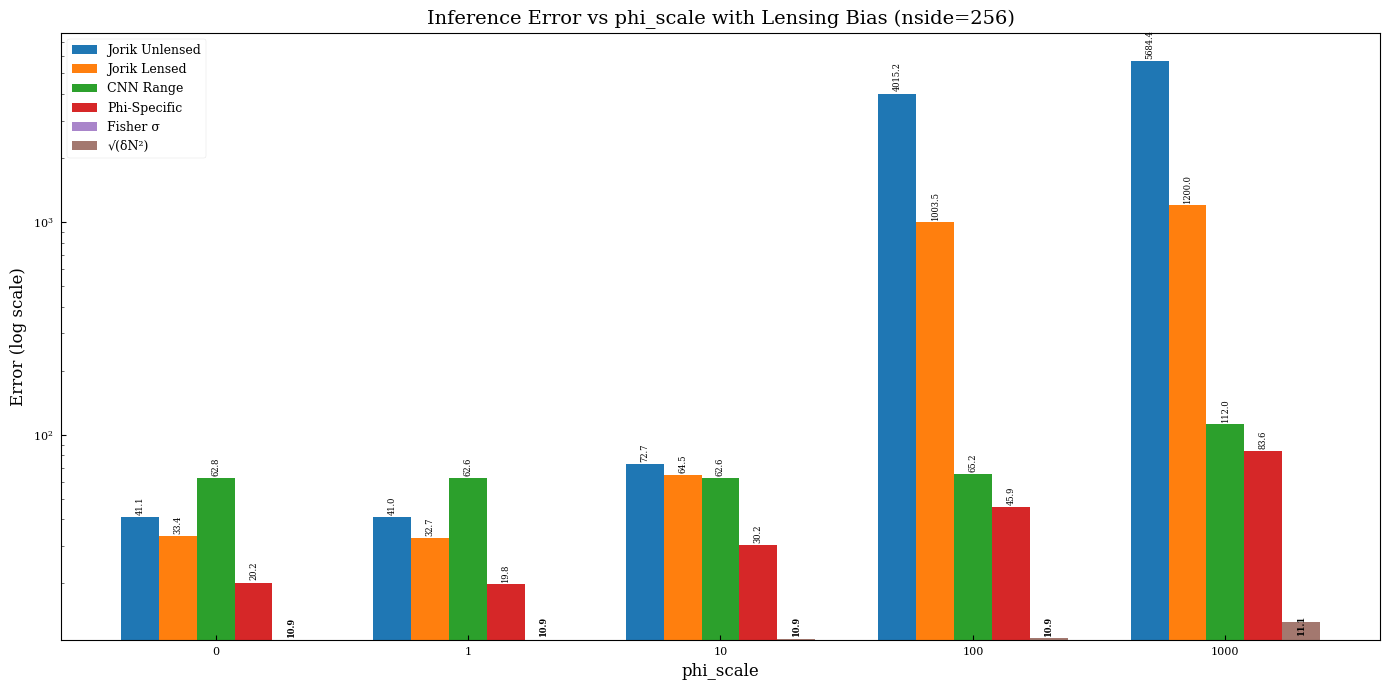


Note: Stacked bar shows Fisher σ (bottom) + √(δN²) lensing bias (top)


In [ ]:
# Stacked bar plot with log y-axis
fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(PHI_SCALES))
width = 0.15

# Model RMSE bars
bars1 = ax.bar(
    x - 2 * width, impact["jorik_unlensed"], width, label="Jorik Unlensed", color="C0"
)
bars2 = ax.bar(
    x - width, impact["jorik_lensed"], width, label="Jorik Lensed", color="C1"
)
bars3 = ax.bar(x, impact["cnn_range"], width, label="CNN Range", color="C2")
bars4 = ax.bar(
    x + width, impact["phi_specific"], width, label="Phi-Specific", color="C3"
)

# Stacked Fisher + delta N²/S² bar
bars_fisher = ax.bar(
    x + 2 * width, fisher_error, width, label="Fisher σ", color="C4", alpha=0.8
)
bars_delta = ax.bar(
    x + 2 * width,
    delta_n2_error,
    width,
    bottom=fisher_error,
    label="√(δN²/S²)",
    color="C5",
    alpha=0.8,
)

# Log scale
ax.set_yscale("log")

ax.set_xticks(x)
ax.set_xticklabels(PHI_SCALES)
ax.set_xlabel("phi_scale", fontsize=12)
ax.set_ylabel("Error (log scale)", fontsize=12)
ax.set_title(
    f"Inference Error vs phi_scale with Lensing Bias (nside={core.nside})", fontsize=14
)
ax.legend(loc="upper left", fontsize=9)
# ax.grid(True, alpha=0.3, axis="y", which="both")


# Add value labels on top of bars (for non-log friendly display)
def add_bar_label(bars, fmt="{:.1f}"):
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.annotate(
                fmt.format(h),
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_y() + h),
                xytext=(0, 3),
                textcoords="offset points",
                ha="center",
                fontsize=6,
                rotation=90,
            )


for bars in [bars1, bars2, bars3, bars4]:
    add_bar_label(bars)

# Label total combined error on stacked bars
for i, (bar, total) in enumerate(zip(bars_fisher, combined_error)):
    ax.annotate(
        f"{total:.1f}",
        xy=(bar.get_x() + bar.get_width() / 2, total),
        xytext=(0, 3),
        textcoords="offset points",
        ha="center",
        fontsize=6,
        fontweight="bold",
        rotation=90,
    )

plt.tight_layout()
plt.show()

print(f"\nNote: Stacked bar shows Fisher σ (bottom) + √(δN²/S²) lensing bias (top)")
print(f"The δN² values are properly normalized by S² = {S_ref**2:.6e}")